###CAT AND DOG CLASSIFICATION

**GOAL:** Create a model that can classify photos as cats and dogs using convolution neural network.





###LOADING LIBRARIES AND DATA

In [ ]:
import os
import kagglehub
from torch.utils.data import DataLoader
import random
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from torchvision import transforms, datasets
import torch
from torch import nn
from tqdm.auto import tqdm
from pathlib import Path
import torchvision
import zipfile
import requests
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
try:
  import torchinfo
  from torchinfo import summary
except:
  %pip install torchinfo
  import torchinfo
  from torchinfo import summary

In [ ]:
path = Path(kagglehub.dataset_download("tongpython/cat-and-dog"))
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/tongpython/cat-and-dog


In [ ]:
train_dir = path / 'training_set' / 'training_set'
test_dir = path / 'test_set' / 'test_set'

###SETUP DEVICE AGNOSTIC CODE
Since we will be creating a deep learning model, It is essential to setup a device agnostic code to use google colab's free GPU. We have to use GPU to train models faster

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

###VISUALIZE A RANDOM IMAGE


Visualize a random image using PIL

image class" dogs | image size (253, 329)


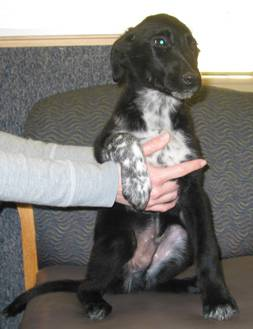

In [ ]:
image_path_list = list(train_dir.glob('*/*.jpg'))
random_image_path = random.choice(image_path_list)
image_class = random_image_path.parent.stem
img = Image.open(random_image_path)

print(f'image class: {image_class} | image size: {img.size}')
img

Visualize a random image using matplotlib

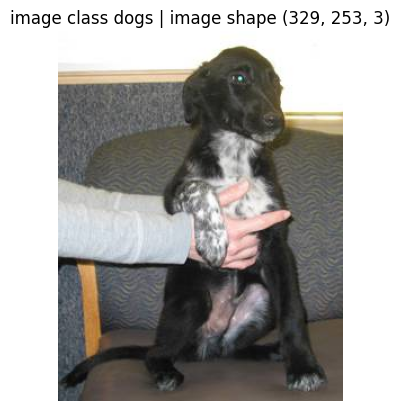

In [ ]:
image_as_array = np.asarray(img)
plt.title(f'image class: {image_class} | image shape: {image_as_array.shape}')
plt.axis(False)
plt.imshow(image_as_array)

###TRANSFORM DATA
Create a transform to use it on image datasets. Transforming images is ideal to standardize inputs, meet model requirements, and artificially expand the dataset.

We give both the train and test dataset their own transform.

We only want to apply data augmentation to our train dataset to avoid overfitting results.

In [ ]:
train_transform = transforms.Compose([transforms.Resize(size=(224, 224)) ,transforms.RandomHorizontalFlip(0.5), transforms.RandomRotation(degrees=25), transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])
test_transform = transforms.Compose([transforms.Resize(size=(224,224)), transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

Visualize a random transformed image

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


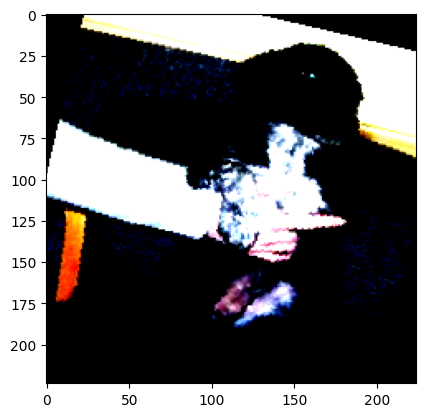

In [ ]:
random_image_transformed = train_transform(img)
plt.imshow(random_image_transformed.permute(1,2,0))

Apply transforms to train_dir and test_dir

In [ ]:
train_data = datasets.ImageFolder(root=train_dir, transform=train_transform)
test_data = datasets.ImageFolder(root=test_dir, transform=test_transform)

In [ ]:
#Get the classes of our datasets
classes = train_data.classes
print(classes)

['cats', 'dogs']


Display 4 random images from train_data

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5877128].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.535425].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.535425].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.8905448].


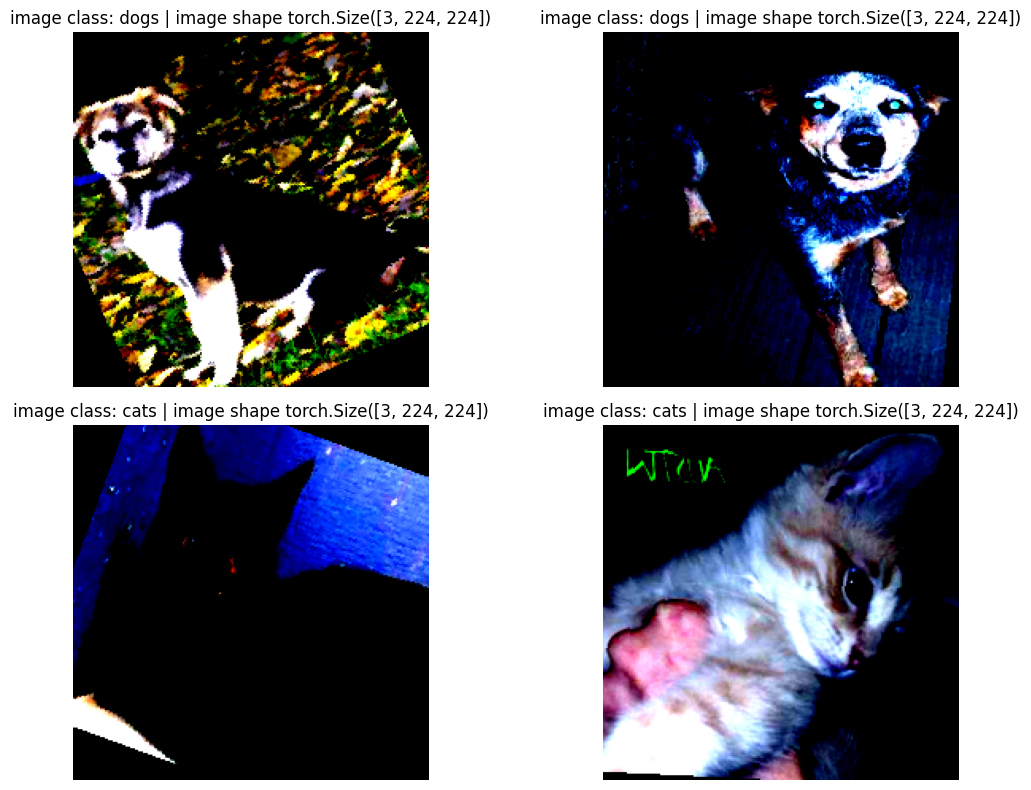

In [ ]:
random_sample_idx = random.sample(range(len(train_data)), k=4)
plt.figure(figsize=(16,8))
for i, targ_sample in enumerate(random_sample_idx):
  targ_image, targ_label = train_data[targ_sample][0], train_data[targ_sample][1]

  plt.subplot(2, 2, i+1)
  plt.imshow(targ_image.permute(1,2,0))
  plt.axis(False)
  plt.title(f'image class: {classes[targ_label]} | image shape {targ_image.shape}')
  plt.tight_layout()

###TURN DATA IMAGES INTO DATALOADERS
The advantage of DataLoaders is that they enable us to perform parallel processing, by allowing multiple items to be handled simultaneously.

In [ ]:
BATCH_SIZE = 64
train_dataloader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, shuffle=False)

View a random image inside a dataloader

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5877128].


Text(0.5, 1.0, 'dogs')

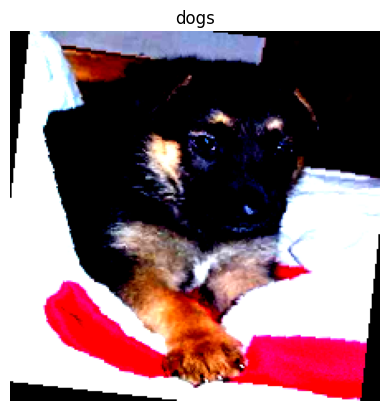

In [ ]:
batch_img, batch_label = next(iter(train_dataloader))
random_batch_img, random_batch_img_label = batch_img[0], batch_label[0]
plt.imshow(random_batch_img.permute(1,2,0))
plt.axis(False)
plt.title(classes[random_batch_img_label])

###CREATE A NEURAL NETWORK MODEL
Building a convolutional neural network from scratch as a baseline.

**ARCHITECTURE:**
- 4 convolutional blocks - Each block has a two `Conv2d` layers that are each followed by `BatchNorm2d` and `ReLU`. It ends with `MaxPool2d` that halves the image size (224 -> 112 -> 56 -> 28 -> 14).
- Classifier - The 14x14 feature maps are flattened and passed through one `Linear` layer that outputs a score for each class (cats, dogs).
- 40 hidden units - Hidden layers in every convolutional layer.

In [ ]:
class nnModel(nn.Module):
  def __init__(self, input_shape, hidden_units, output_shape):
    super().__init__()
    self.Conv_layer_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(hidden_units),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(hidden_units),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )
    self.Conv_layer_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(hidden_units),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(hidden_units),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )
    self.Conv_layer_3 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(hidden_units),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(hidden_units),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )
    self.Conv_layer_4 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(hidden_units),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(hidden_units),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*14*14, out_features=output_shape)
    )

  def forward(self, x):
    x = self.Conv_layer_1(x)
    x = self.Conv_layer_2(x)
    x = self.Conv_layer_3(x)
    x = self.Conv_layer_4(x)
    x= self.classifier(x)
    return x

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
model = nnModel(input_shape=3, hidden_units=40, output_shape=len(classes)).to(device)

Use `torchinfo` to get an idea of the shapes going through our model

In [ ]:
summary(model, input_size=[1, 3, 224, 224])

Layer (type:depth-idx)                   Output Shape              Param #
nnModel                                  [1, 2]                    --
├─Sequential: 1-1                        [1, 40, 112, 112]         --
│    └─Conv2d: 2-1                       [1, 40, 224, 224]         1,120
│    └─BatchNorm2d: 2-2                  [1, 40, 224, 224]         80
│    └─ReLU: 2-3                         [1, 40, 224, 224]         --
│    └─Conv2d: 2-4                       [1, 40, 224, 224]         14,440
│    └─BatchNorm2d: 2-5                  [1, 40, 224, 224]         80
│    └─ReLU: 2-6                         [1, 40, 224, 224]         --
│    └─MaxPool2d: 2-7                    [1, 40, 112, 112]         --
├─Sequential: 1-2                        [1, 40, 56, 56]           --
│    └─Conv2d: 2-8                       [1, 40, 112, 112]         14,440
│    └─BatchNorm2d: 2-9                  [1, 40, 112, 112]         80
│    └─ReLU: 2-10                        [1, 40, 112, 112]         --
│   

###CREATE A TRAIN AND TEST LOOP FUNCTIONS

We functionize the training loop of the model for reproducibility

In [ ]:
def train_step(model, dataloader, loss_fn, optimizer, device):
  model.train()
  train_loss, train_acc = 0, 0

  for X, y in dataloader:
    X, y = X.to(device), y.to(device)
    y_pred = model(X)
    loss = loss_fn(y_pred, y)
    train_loss+= loss.item()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
    train_acc+= (y_pred_class == y).sum().item() / len(y_pred_class)

  train_loss = train_loss / len(dataloader)
  train_acc = train_acc / len(dataloader)

  return train_loss, train_acc

In [ ]:
def test_step(model, dataloader, loss_fn, device):
  model.eval()
  test_loss, test_acc = 0, 0

  with torch.inference_mode():
    for X, y in dataloader:
      X, y = X.to(device), y.to(device)
      test_pred = model(X)
      loss = loss_fn(test_pred, y)
      test_loss+=loss.item()

      test_pred_class = torch.argmax(torch.softmax(test_pred, dim=1), dim=1)
      test_acc+= (test_pred_class ==y).sum().item() / len(test_pred_class)

    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

In [ ]:
def train(model: torch.nn.Module, train_dataloader:torch.utils.data.DataLoader, test_dataloader:torch.utils.data.DataLoader,
          loss_fn:torch.nn.Module, optimizer:torch.optim.Optimizer, epochs:int = 5, device=device):

  results={'train_loss':[], 'train_acc':[], 'test_loss':[], 'test_acc':[]}

  for epoch in tqdm(range(epochs)):
    train_loss, train_acc = train_step(model, train_dataloader, loss_fn, optimizer, device)
    test_loss, test_acc = test_step(model, test_dataloader, loss_fn, device)

    print(f'Epoch: {epoch} | train_loss: {train_loss:.4f} | train_acc: {train_acc:.4f} | test_loss: {test_loss:.4f} | test_acc: {test_acc:.4f}')
    results['train_loss'].append(train_loss)
    results['train_acc'].append(train_acc)
    results['test_loss'].append(test_loss)
    results['test_acc'].append(test_acc)
  return results

I also included a classify function to get the predicted results of the model. We will then create a confusion matrix later to further analyze the results

In [ ]:
def classify(model, dataloader, device=device):
  model.eval()
  preds, labels = [], []
  with torch.inference_mode():
    for X, y in dataloader:
        X, y = X.to(device), y.to(device)
        pred = model(X)
        pred = torch.argmax(torch.softmax(pred, dim=1), dim=1)
        preds.append(pred.cpu())
        labels.append(y.cpu())
    return torch.cat(preds), torch.cat(labels)

###EVALUATE MODEL

In [ ]:
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)
loss_fn = torch.nn.CrossEntropyLoss()
torch.manual_seed(42)
torch.cuda.manual_seed(42)
model_results = train(model, train_dataloader, test_dataloader, loss_fn, optimizer, device=device)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0 | train_loss: 0.7829 | train_acc: 0.5920 | test_loss: 0.6258 | test_acc: 0.6529
Epoch: 1 | train_loss: 0.6320 | train_acc: 0.6604 | test_loss: 0.6754 | test_acc: 0.6326
Epoch: 2 | train_loss: 0.6051 | train_acc: 0.6854 | test_loss: 0.5784 | test_acc: 0.6884
Epoch: 3 | train_loss: 0.5580 | train_acc: 0.7119 | test_loss: 0.5605 | test_acc: 0.7139
Epoch: 4 | train_loss: 0.5225 | train_acc: 0.7397 | test_loss: 0.5138 | test_acc: 0.7430


###PLOT THE RESULTS OF THE MODEL

In [ ]:
def plot_results(results):
  train_loss = results['train_loss']
  train_acc = results['train_acc']
  test_loss = results['test_loss']
  test_acc = results['test_acc']

  epochs = range(len(results['train_loss']))

  plt.figure(figsize=(15, 7))

  plt.subplot(1, 2, 1)
  plt.plot(epochs, train_loss, label='train_loss')
  plt.plot(epochs, test_loss, label='test_loss')
  plt.title('LOSS')
  plt.xlabel('Epochs')
  plt.legend()

  plt.subplot(1, 2, 2)
  plt.plot(epochs, train_acc, label='train_acc')
  plt.plot(epochs, test_acc, label='test_acc')
  plt.title('ACCURACY')
  plt.xlabel('Epochs')
  plt.legend()

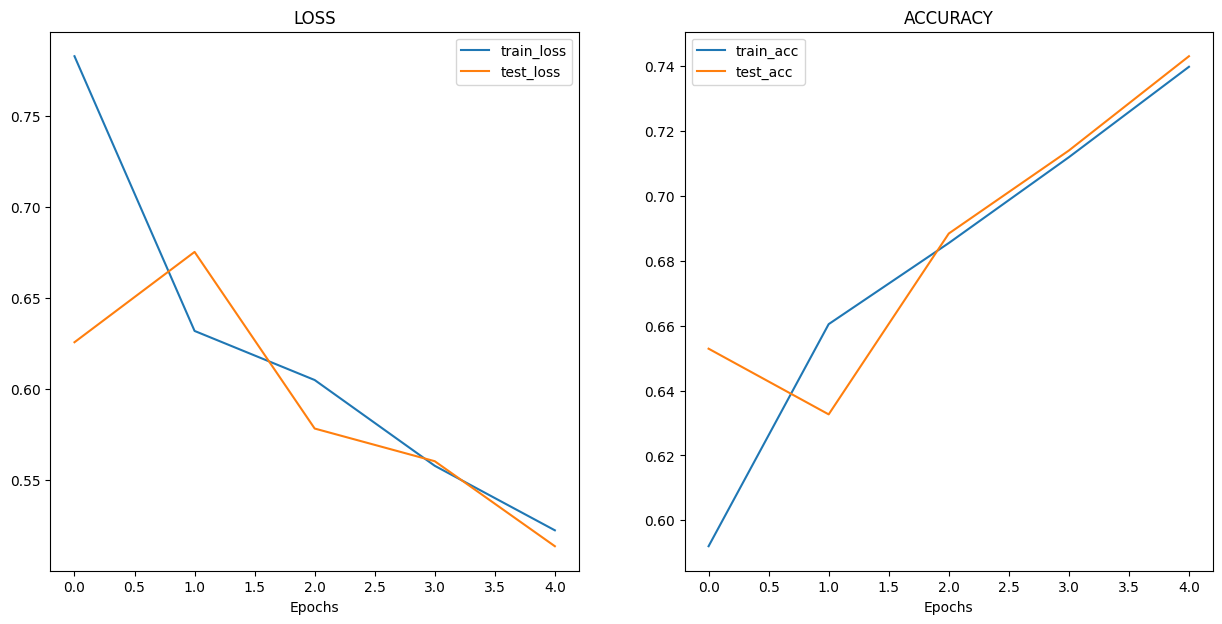

In [ ]:
plot_results(model_results)

###CLASSIFY THE WHOLE TEST SET

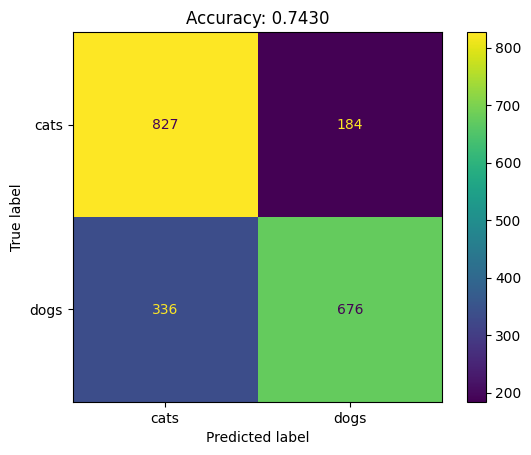

In [ ]:
preds, labels = classify(model, test_dataloader, device=device)
ConfusionMatrixDisplay(confusion_matrix(labels, preds), display_labels=classes).plot()
plt.title(f'Accuracy: {(preds == labels).float().mean():.4f}')
plt.show()

Based on the given plot, the baseline model is doing okay when it comes to classifying cats and dogs. It's not ideal though because the accuracy is only around 70%. We want our model to be around 85% - 95% accuracy. Maybe if we train our model a little longer it might get around the 80% accuracy range but we would add more epochs thus more GPU compute time.

###TRANSFER LEARNING (EfficientNet-B0)

To get better results, We can do **transfer learning**.

**Transfer learning** is a machine learning technique in which knowledge gained through one task or dataset is used to improve model performance on another related task or different dataset. In other words, transfer learning uses what has been learned in one setting to improve generalization in another setting.

For this case, we'll be using torchvision's EfficientNet_b0

https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.efficientnet_b0.html#torchvision.models.EfficientNet_B0_Weights

###SETTING UP PRETRAINED MODEL

In [ ]:
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
tl_model = torchvision.models.efficientnet_b0(weights=weights).to(device)
tl_model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

Get a summary of our model with  `torchinfo.summary()`

In [ ]:
summary(model=tl_model, input_size=(1, 3, 224, 224), col_names=['input_size', 'output_size', 'num_params', 'trainable'], col_width=20, row_settings=['var_names'])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 1000]            --                   True
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1280, 7, 7]      --                   True
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   True
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    864                  True
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    64                   True
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 16, 112,

###FREEZING THE BASE MODEL AND CHANGING THE OUTPUT LAYER

Freeze all of the base layers of EffNetB0

In [ ]:
for param in tl_model.features.parameters():
  param.requires_grad = False

In [ ]:
summary(model=tl_model, input_size=(1, 3, 224, 224), col_names=['input_size', 'output_size', 'num_params', 'trainable'], col_width=20, row_settings=['var_names'])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 1000]            --                   Partial
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1280, 7, 7]      --                   False
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    (864)                False
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    (64)                 False
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 1

Update the classifier head of our model to suit our problem

In [ ]:
tl_model.classifier

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
tl_model.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(in_features=1280, out_features=len(classes))
).to(device)
tl_model.classifier

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)

In [ ]:
summary(model=tl_model, input_size=(1, 3, 224, 224), col_names=['input_size', 'output_size', 'num_params', 'trainable'], col_width=20, row_settings=['var_names'])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 2]               --                   Partial
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1280, 7, 7]      --                   False
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    (864)                False
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    (64)                 False
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 1

###TRAIN `tl_model`
We will be using the same loss function we used from the previous model.

In [ ]:
tl_optimizer = torch.optim.Adam(params=tl_model.parameters(), lr=0.001)
tl_model_results = train(tl_model, train_dataloader, test_dataloader, loss_fn, tl_optimizer, device=device)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0 | train_loss: 0.2757 | train_acc: 0.9019 | test_loss: 0.1687 | test_acc: 0.9408
Epoch: 1 | train_loss: 0.1741 | train_acc: 0.9356 | test_loss: 0.1464 | test_acc: 0.9515
Epoch: 2 | train_loss: 0.1601 | train_acc: 0.9379 | test_loss: 0.1348 | test_acc: 0.9535
Epoch: 3 | train_loss: 0.1360 | train_acc: 0.9483 | test_loss: 0.1232 | test_acc: 0.9513
Epoch: 4 | train_loss: 0.1390 | train_acc: 0.9463 | test_loss: 0.1199 | test_acc: 0.9571


###PLOT THE RESULTS OF THE MODEL

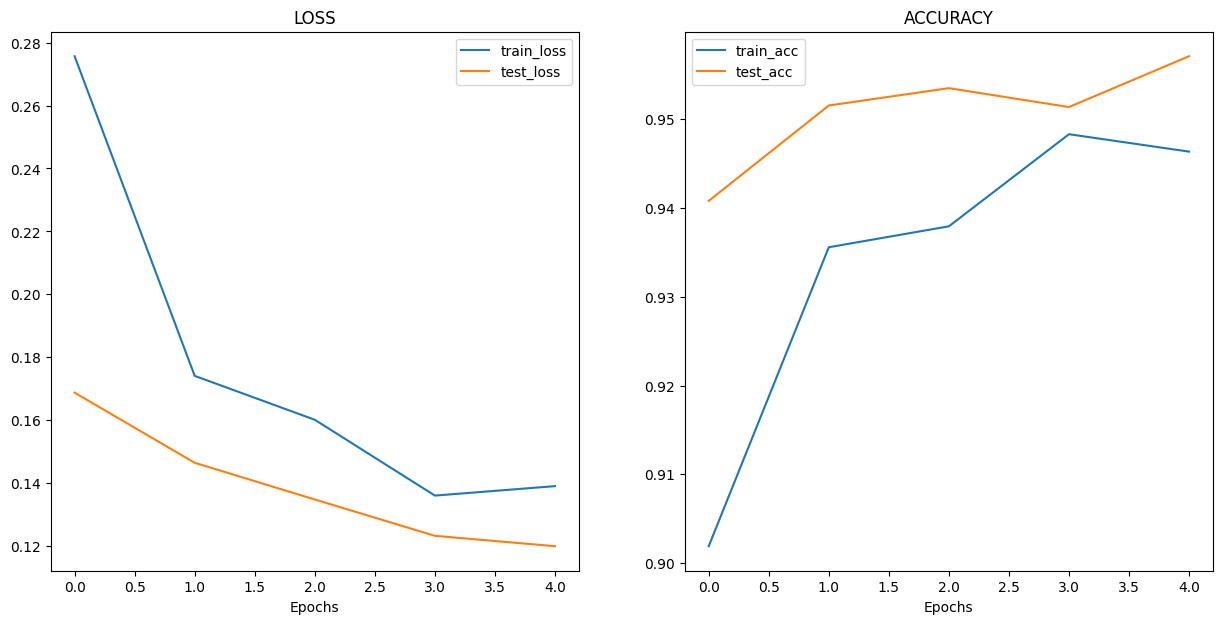

In [ ]:
plot_results(tl_model_results)

###COMPARE 1ST MODEL AND SECOND MODEL

We can clearly see based from the results that our pretrained model has better results than our baseline model.

For the first 5 epochs:

**1st model accuracy:** 65-75%

**2nd model accuracy:** 94-95%

`tl_model` wins

###CLASSIFY THE WHOLE TEST SET

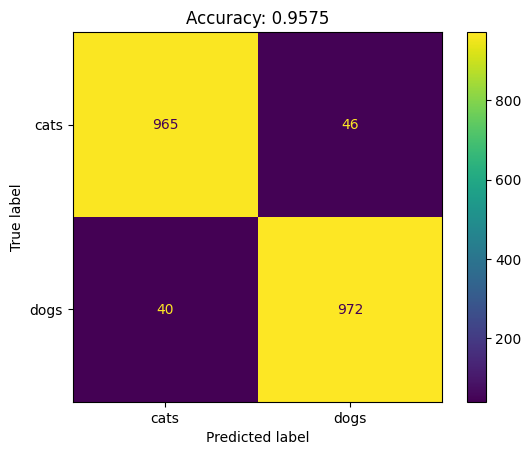

In [ ]:
preds, labels = classify(tl_model, test_dataloader, device=device)
ConfusionMatrixDisplay(confusion_matrix(labels, preds), display_labels=classes).plot()
plt.title(f'Accuracy: {(preds == labels).float().mean():.4f}')
plt.show()

Based on the given plot, the transfer learning model does very well in classifying cats and dogs. It did better than our baseline model. It has more correct predictions and way less mistakes.



Plot the first 6 misclassified images

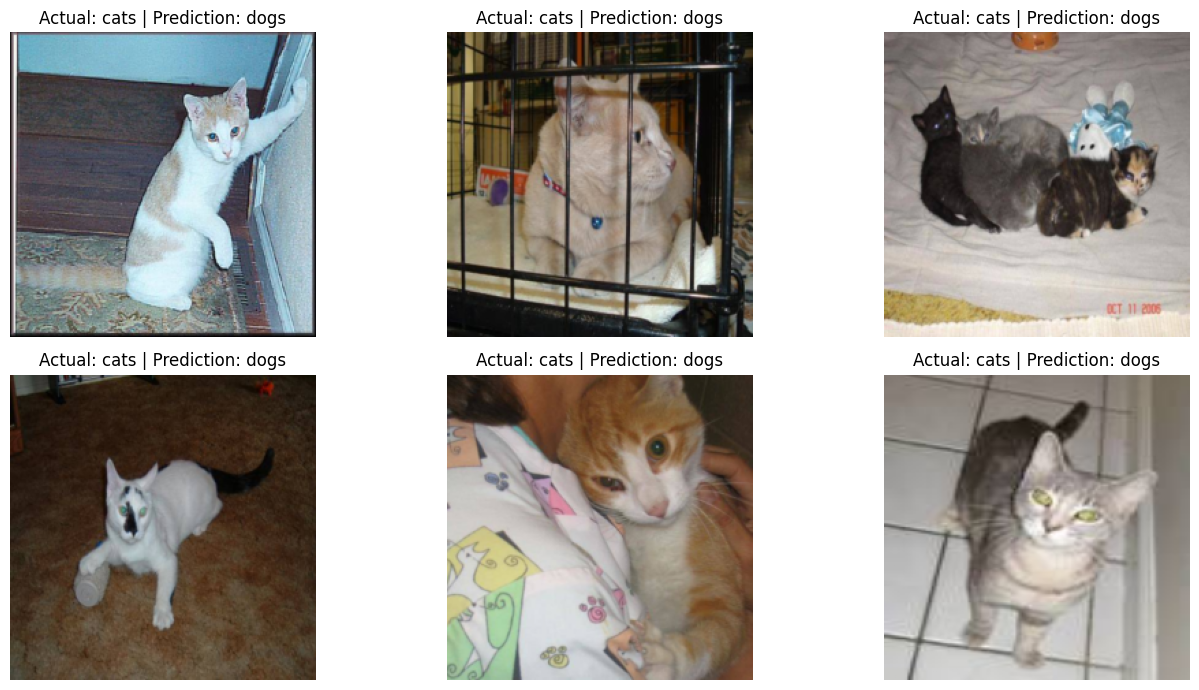

In [ ]:
mean = torch.tensor([0.485, 0.456, 0.406]).reshape(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).reshape(3, 1, 1)

wrong = (preds != labels).nonzero().flatten()
wrong = wrong[torch.randperm(len(wrong))[:6]]
plt.figure(figsize=(14, 7))
for i, idx in enumerate(wrong):
  img, label = test_data[idx.item()]
  img = (img*std+mean).clamp(0,1)
  plt.subplot(2, 3, i+1)
  plt.imshow(img.permute(1,2,0))
  plt.title(f'Actual: {classes[label]} | Prediction: {classes[preds[idx]]}')
  plt.axis(False)
plt.tight_layout()
plt.show()

###CLASSIFY CUSTOM IMAGES USING `tl_model`

Let's see how well our transfer learning model classify custom images that are not from the train and test set.

Download the custom_images.zip from my github repo and unzip it

In [ ]:
data_path = Path('data/')

if not data_path.is_dir():
  data_path.mkdir(exist_ok=True, parents=True)

with open(data_path / 'custom_images.zip', 'wb') as f:
  request = requests.get('https://github.com/Albertt-Carlsonn/machine-learning-portfolio/raw/refs/heads/main/cats_and_dogs_classifier/custom_images.zip')
  print('downloading custom_images data...')
  f.write(request.content)

with zipfile.ZipFile(data_path / 'custom_images.zip', 'r') as zip_ref:
  print('unzipping custom_images data...')
  zip_ref.extractall(data_path)

downloading custom_images data...
unzipping custom_images data...


In [ ]:
custom_image1 = torchvision.io.read_image(str(data_path / 'cat1.jpg')).type(torch.float) / 255
custom_image2 = torchvision.io.read_image(str(data_path / 'cat2.jpg')).type(torch.float) / 255
custom_image3 = torchvision.io.read_image(str(data_path / 'dog1.jpg')).type(torch.float) / 255
custom_image4 = torchvision.io.read_image(str(data_path / 'dog2.jpg')).type(torch.float) / 255

Visualize the custom images

(np.float64(-0.5), np.float64(999.5), np.float64(740.5), np.float64(-0.5))

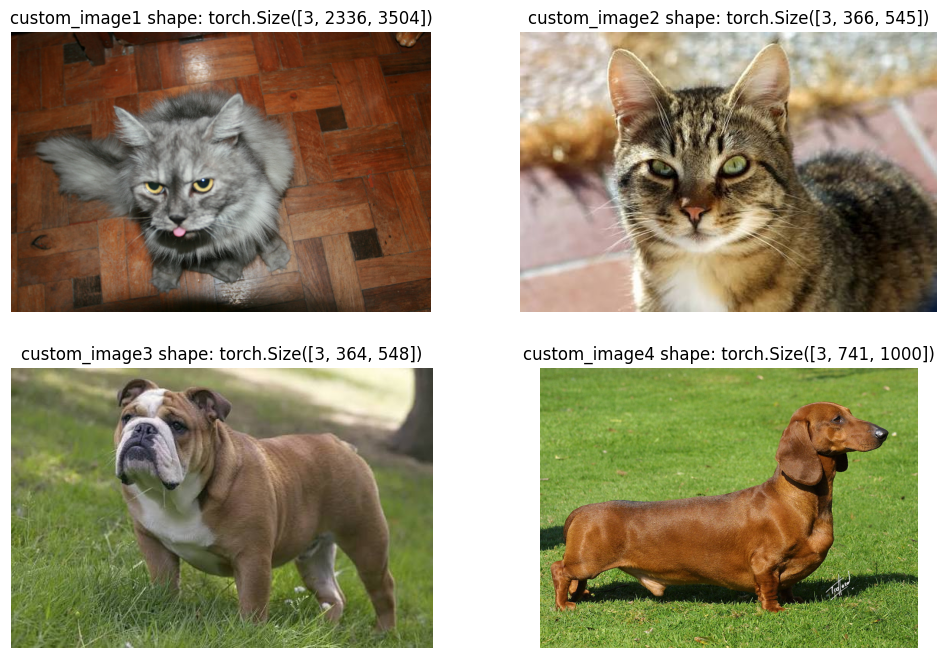

In [ ]:
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.imshow(custom_image1.permute(1,2,0))
plt.title(f'custom_image1 shape: {custom_image1.shape}')
plt.axis(False)
plt.subplot(2, 2, 2)
plt.imshow(custom_image2.permute(1,2,0))
plt.title(f'custom_image2 shape: {custom_image2.shape}')
plt.axis(False)
plt.subplot(2, 2, 3)
plt.imshow(custom_image3.permute(1,2,0))
plt.title(f'custom_image3 shape: {custom_image3.shape}')
plt.axis(False)
plt.subplot(2, 2, 4)
plt.imshow(custom_image4.permute(1,2,0))
plt.title(f'custom_image4 shape: {custom_image4.shape}')
plt.axis(False)



Create a transformation for custom images. Must be the same transformation our model been trained on. You can just copy test set's transformation.

**DO NOT** add a `transforms.ToTensor()` because we already converted the image into tensor.

In [ ]:
custom_image_transform = transforms.Compose([transforms.Resize(size=(224,224)),
                                             transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                              std=[0.229, 0.224, 0.225])])
custom_image1_transformed = custom_image_transform(custom_image1)
custom_image2_transformed = custom_image_transform(custom_image2)
custom_image3_transformed = custom_image_transform(custom_image3)
custom_image4_transformed = custom_image_transform(custom_image4)

Visualize the transformed custom images

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0960715..2.1288307].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1164691..2.6315382].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8988159..2.5175843].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.989363..1.980052].


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

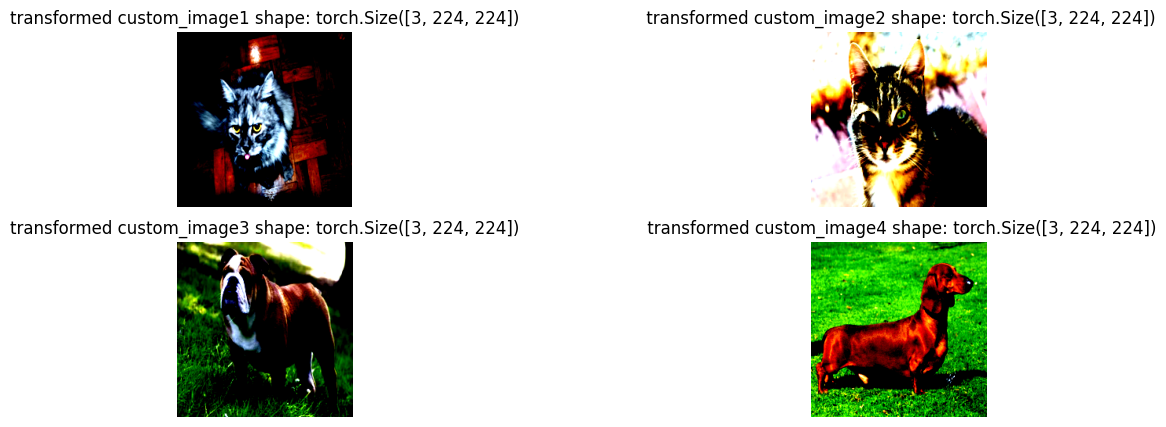

In [ ]:
plt.figure(figsize=(15, 5))
plt.subplot(2, 2, 1)
plt.imshow(custom_image1_transformed.permute(1,2,0))
plt.title(f'transformed custom_image1 shape: {custom_image1_transformed.shape}')
plt.axis(False)
plt.subplot(2, 2, 2)
plt.imshow(custom_image2_transformed.permute(1,2,0))
plt.title(f' transformed custom_image2 shape: {custom_image2_transformed.shape}')
plt.axis(False)
plt.subplot(2, 2, 3)
plt.imshow(custom_image3_transformed.permute(1,2,0))
plt.title(f'transformed custom_image3 shape: {custom_image3_transformed.shape}')
plt.axis(False)
plt.subplot(2, 2, 4)
plt.imshow(custom_image4_transformed.permute(1,2,0))
plt.title(f' transformed custom_image4 shape: {custom_image4_transformed.shape}')
plt.axis(False)


Classify the transformed custom images using `tl_model`

Unsqueeze the transformed custom images because our model was trained in batches.

In [ ]:
tl_model.eval()
with torch.inference_mode():
  pred1 = tl_model(custom_image1_transformed.unsqueeze(0).to(device))
  pred1_class = torch.argmax(torch.softmax(pred1, dim=1), dim=1)
  pred1_class = classes[pred1_class]

  pred2 = tl_model(custom_image2_transformed.unsqueeze(0).to(device))
  pred2_class = torch.argmax(torch.softmax(pred2, dim=1), dim=1)
  pred2_class = classes[pred2_class]

  pred3 = tl_model(custom_image3_transformed.unsqueeze(0).to(device))
  pred3_class = torch.argmax(torch.softmax(pred3, dim=1), dim=1)
  pred3_class = classes[pred3_class]

  pred4 = tl_model(custom_image4_transformed.unsqueeze(0).to(device))
  pred4_class = torch.argmax(torch.softmax(pred4, dim=1), dim=1)
  pred4_class = classes[pred4_class]

(np.float64(-0.5), np.float64(999.5), np.float64(740.5), np.float64(-0.5))

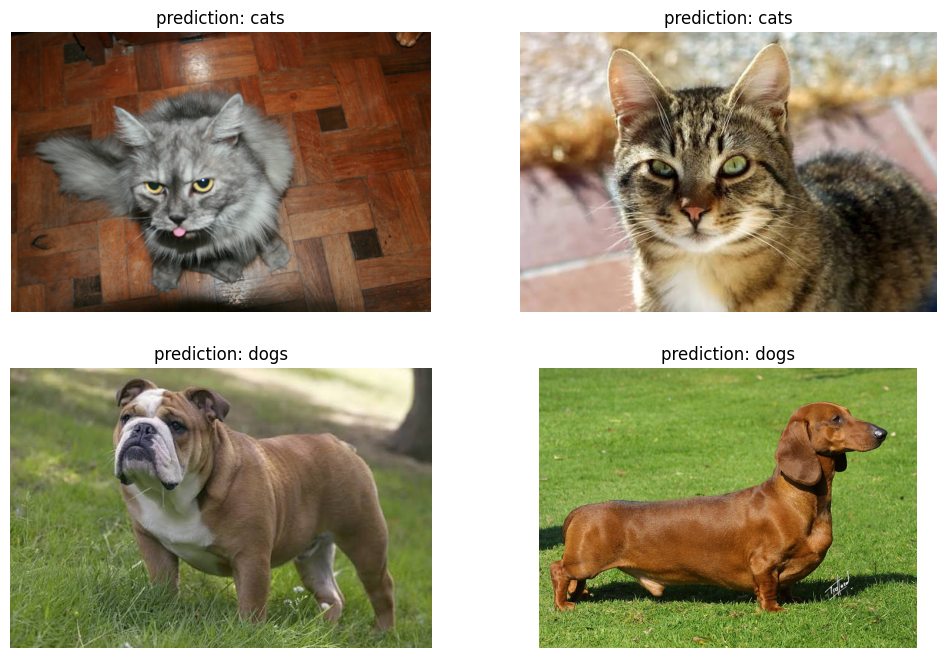

In [ ]:
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.imshow(custom_image1.permute(1,2,0))
plt.title(f'prediction: {pred1_class}')
plt.axis(False)
plt.subplot(2, 2, 2)
plt.imshow(custom_image2.permute(1,2,0))
plt.title(f'prediction: {pred2_class}')
plt.axis(False)
plt.subplot(2, 2, 3)
plt.imshow(custom_image3.permute(1,2,0))
plt.title(f'prediction: {pred3_class}')
plt.axis(False)
plt.subplot(2, 2, 4)
plt.imshow(custom_image4.permute(1,2,0))
plt.title(f'prediction: {pred4_class}')
plt.axis(False)



###CONCLUSION

Our transfer learning model beat our baseline model. It has a much higher accuracy of 95% with only 5 epochs. It is able to classify cats and dogs better than our baseline model.